# Stage 4 — Blend Residual-Corrected Forecasts

**Mục tiêu:**
- Load backtest predictions từ Stage 3 (`2021-01-01 -> 2022-12-31`)
- So sánh 3 đường dự báo: `Prophet trend`, `Prophet + LGBM residual`, `Prophet + CatBoost residual`
- Tối ưu blend giữa hai đường residual-corrected trên holdout
- Áp dụng weights lên future predictions và lưu output cuối

**Inputs:** `oof_predictions.csv`, `test_predictions.csv`  
**Outputs:** `ensemble_predictions.csv`, `ensemble_weights.json`, `oof_ensemble.csv`

In [1]:
import pandas as pd
import numpy as np
import json
import os
import warnings
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

OUTPUT_DIR = r'd:\datathon_2026\train_model\Datathon_2026'

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def score_report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r   = rmse(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f'  {name:35s}  MAE={mae:>12,.0f}  RMSE={r:>12,.0f}  R2={r2:.4f}')
    return {'mae': mae, 'rmse': r, 'r2': r2}

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load OOF & Test Predictions

In [2]:
oof  = pd.read_csv(os.path.join(OUTPUT_DIR, 'oof_predictions.csv'), parse_dates=['date'])
test = pd.read_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), parse_dates=['date'])

print(f'OOF  rows : {len(oof)}')
print(f'Test rows : {len(test)}')
print(f'OOF  cols : {oof.columns.tolist()}')
print(f'Test cols : {test.columns.tolist()}')
oof.head(3)

OOF  rows : 730
Test rows : 548
OOF  cols : ['date', 'Revenue_true', 'COGS_true', 'prophet_trend_oof', 'lgbm_residual_oof', 'cb_residual_oof', 'lgbm_rev_oof', 'cb_rev_oof', 'prophet_trend_cogs_oof', 'lgbm_residual_cogs_oof', 'cb_residual_cogs_oof', 'lgbm_cogs_oof', 'cb_cogs_oof']
Test cols : ['date', 'prophet_rev', 'lgbm_residual', 'catboost_residual', 'lgbm_rev', 'catboost_rev', 'prophet_cogs', 'lgbm_residual_cogs', 'catboost_residual_cogs', 'lgbm_cogs', 'catboost_cogs']


,date,Revenue_true,COGS_true,prophet_trend_oof,lgbm_residual_oof,cb_residual_oof,lgbm_rev_oof,cb_rev_oof,prophet_trend_cogs_oof,lgbm_residual_cogs_oof,cb_residual_cogs_oof,lgbm_cogs_oof,cb_cogs_oof
0,2021-01-01,1553431.51,1547553.58,1.668310e+06,-168638.615788,-365209.252517,1.499672e+06,1.303101e+06,1.724727e+06,-471896.078814,-349784.493877,1.252831e+06,1.374943e+06
1,2021-01-02,378420.41,311258.46,1.326083e+06,-743507.860103,-358726.160667,5.825751e+05,9.673568e+05,1.054643e+06,-411358.713761,-62325.237479,6.432840e+05,9.923175e+05
2,2021-01-03,677894.56,516308.19,1.547816e+06,-766731.961308,-744912.030819,7.810840e+05,8.029040e+05,1.231393e+06,-486056.610582,-215408.060730,7.453361e+05,1.015985e+06


## 2. Single-Model OOF Baseline

In [3]:
y_rev_oof = oof['Revenue_true'].values
prophet_oof = oof['prophet_trend_oof'].values
lgbm_oof_rev = oof['lgbm_rev_oof'].values
cb_oof_rev = oof['cb_rev_oof'].values

y_cogs_oof = oof['COGS_true'].values if 'COGS_true' in oof.columns else None
prophet_oof_cogs = oof['prophet_trend_cogs_oof'].values if 'prophet_trend_cogs_oof' in oof.columns else None
lgbm_oof_cogs = oof['lgbm_cogs_oof'].values if 'lgbm_cogs_oof' in oof.columns else None
cb_oof_cogs = oof['cb_cogs_oof'].values if 'cb_cogs_oof' in oof.columns else None

print('=== Holdout Baseline (2021-2022) — Revenue ===')
s_prophet = score_report('Prophet trend', y_rev_oof, prophet_oof)
s_lgbm_rev = score_report('Prophet + LGBM residual', y_rev_oof, lgbm_oof_rev)
s_cb_rev = score_report('Prophet + CatBoost residual', y_rev_oof, cb_oof_rev)

if y_cogs_oof is not None and lgbm_oof_cogs is not None and cb_oof_cogs is not None:
    print('\n=== Holdout Baseline (2021-2022) — COGS ===')
    s_prophet_cogs = score_report('Prophet trend (COGS)', y_cogs_oof, prophet_oof_cogs)
    s_lgbm_cogs = score_report('Prophet + LGBM residual (COGS)', y_cogs_oof, lgbm_oof_cogs)
    s_cb_cogs = score_report('Prophet + CatBoost residual (COGS)', y_cogs_oof, cb_oof_cogs)
else:
    s_prophet_cogs = s_lgbm_cogs = s_cb_cogs = None
    print('\nCOGS OOF columns not found -> COGS ensemble will be skipped.')

=== Holdout Baseline (2021-2022) — Revenue ===
  Prophet trend                        MAE=     905,367  RMSE=   1,334,063  R2=0.3595
  Prophet + LGBM residual              MAE=     742,149  RMSE=   1,057,129  R2=0.5978
  Prophet + CatBoost residual          MAE=     750,841  RMSE=   1,078,715  R2=0.5812

=== Holdout Baseline (2021-2022) — COGS ===
  Prophet trend (COGS)                 MAE=     816,727  RMSE=   1,196,421  R2=0.3195
  Prophet + LGBM residual (COGS)       MAE=     667,786  RMSE=     928,937  R2=0.5898
  Prophet + CatBoost residual (COGS)   MAE=     718,228  RMSE=   1,004,264  R2=0.5206


## 3. Optimise Blend Weights (scipy SLSQP — minimise MAE)

In [4]:
def make_blend_mae(pred_a, pred_b, y_true):
    def _loss(w):
        w = np.clip(w, 0, 1)
        w = w / w.sum()
        return mean_absolute_error(y_true, w[0] * pred_a + w[1] * pred_b)
    return _loss

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
bounds = [(0.0, 1.0), (0.0, 1.0)]
w0 = [0.5, 0.5]

res_rev = minimize(
    make_blend_mae(lgbm_oof_rev, cb_oof_rev, y_rev_oof),
    w0, method='SLSQP', bounds=bounds, constraints=constraints,
    options={'ftol': 1e-9, 'maxiter': 1000}
 )

w_rev = np.clip(res_rev.x, 0, 1)
w_rev /= w_rev.sum()
print(f'Optimised Revenue blend — Prophet+LGBM={w_rev[0]:.4f}   Prophet+CatBoost={w_rev[1]:.4f}')

if y_cogs_oof is not None and lgbm_oof_cogs is not None and cb_oof_cogs is not None:
    res_cogs = minimize(
        make_blend_mae(lgbm_oof_cogs, cb_oof_cogs, y_cogs_oof),
        w0, method='SLSQP', bounds=bounds, constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000}
    )
    w_cogs = np.clip(res_cogs.x, 0, 1)
    w_cogs /= w_cogs.sum()
    print(f'Optimised COGS blend    — Prophet+LGBM={w_cogs[0]:.4f}   Prophet+CatBoost={w_cogs[1]:.4f}')
else:
    w_cogs = np.array([1.0, 0.0])

Optimised Revenue blend — Prophet+LGBM=0.5559   Prophet+CatBoost=0.4441
Optimised COGS blend    — Prophet+LGBM=1.0000   Prophet+CatBoost=0.0000


## 4. OOF Score: Simple Average vs Optimised Blend

In [5]:
simple_rev = 0.5 * lgbm_oof_rev + 0.5 * cb_oof_rev
opt_oof_rev = w_rev[0] * lgbm_oof_rev + w_rev[1] * cb_oof_rev

print('=== Holdout Blend Comparison — Revenue ===')
score_report('Simple Avg residual-corrected', y_rev_oof, simple_rev)
print()
s_ens_rev = score_report('Optimised residual blend', y_rev_oof, opt_oof_rev)

if y_cogs_oof is not None and lgbm_oof_cogs is not None and cb_oof_cogs is not None:
    simple_cogs = 0.5 * lgbm_oof_cogs + 0.5 * cb_oof_cogs
    opt_oof_cogs = w_cogs[0] * lgbm_oof_cogs + w_cogs[1] * cb_oof_cogs
    print('\n=== Holdout Blend Comparison — COGS ===')
    score_report('Simple Avg residual-corrected (COGS)', y_cogs_oof, simple_cogs)
    print()
    s_ens_cogs = score_report('Optimised residual blend (COGS)', y_cogs_oof, opt_oof_cogs)
else:
    opt_oof_cogs = None
    s_ens_cogs = None

=== Holdout Blend Comparison — Revenue ===
  Simple Avg residual-corrected        MAE=     710,445  RMSE=   1,014,425  R2=0.6297

  Optimised residual blend             MAE=     710,008  RMSE=   1,013,842  R2=0.6301

=== Holdout Blend Comparison — COGS ===
  Simple Avg residual-corrected (COGS)  MAE=     683,940  RMSE=     954,995  R2=0.5665

  Optimised residual blend (COGS)      MAE=     667,786  RMSE=     928,937  R2=0.5898


## 5. Visualise: OOF Actual vs Predicted

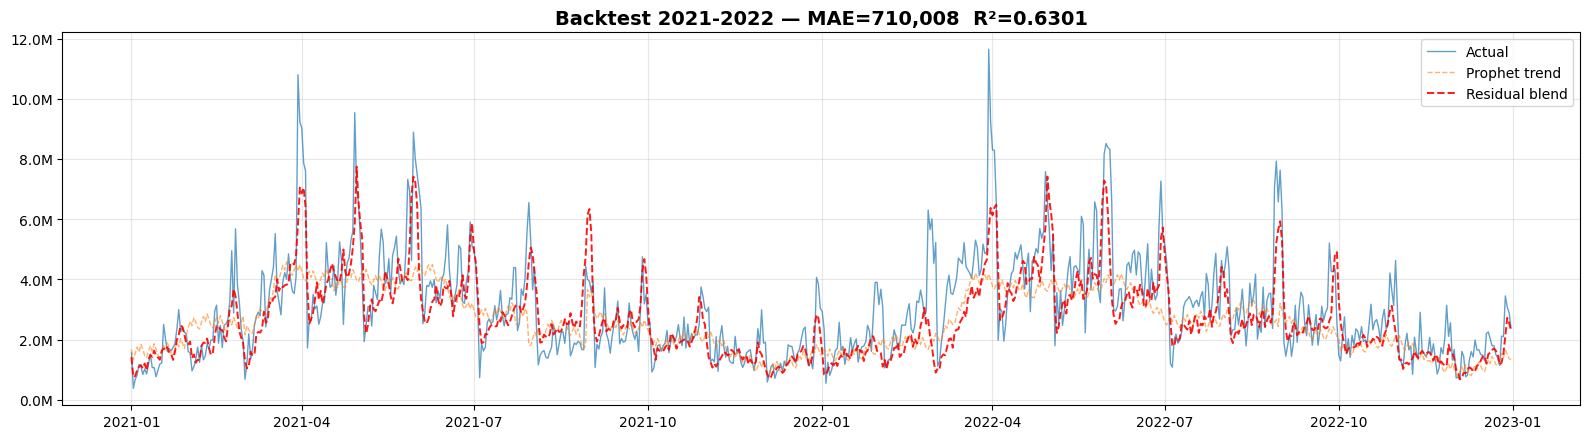

Plot saved: ensemble_oof_plot.png


In [6]:
plt.figure(figsize=(16, 4.5))
oof2 = oof.sort_values('date').reset_index(drop=True)
dates2 = oof2['date']
y2_rev = oof2['Revenue_true'].values
ens2_rev = w_rev[0] * oof2['lgbm_rev_oof'].values + w_rev[1] * oof2['cb_rev_oof'].values

plt.plot(dates2, y2_rev, label='Actual', alpha=0.7, lw=1)
plt.plot(dates2, oof2['prophet_trend_oof'].values, label='Prophet trend', alpha=0.6, lw=1, linestyle='--')
plt.plot(dates2, ens2_rev, label='Residual blend', alpha=0.9, lw=1.4, linestyle='--', color='red')
plt.title(f'Backtest 2021-2022 — MAE={s_ens_rev["mae"]:,.0f}  R²={s_ens_rev["r2"]:.4f}', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ensemble_oof_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: ensemble_oof_plot.png')

## 6. Test Predictions — Apply Ensemble Weights

In [7]:
prophet_test_rev = test['prophet_rev'].values
lgbm_test_rev = test['lgbm_rev'].values
cb_test_rev = test['catboost_rev'].values

ensemble_rev = np.clip(w_rev[0] * lgbm_test_rev + w_rev[1] * cb_test_rev, 0, None)

print(f'Prophet trend only         mean={prophet_test_rev.mean():>12,.0f}')
print(f'Prophet + LGBM residual    mean={lgbm_test_rev.mean():>12,.0f}')
print(f'Prophet + CatBoost residual mean={cb_test_rev.mean():>12,.0f}')
print(f'Optimised residual blend   mean={ensemble_rev.mean():>12,.0f}')

if 'lgbm_cogs' in test.columns and 'catboost_cogs' in test.columns:
    prophet_test_cogs = test['prophet_cogs'].values if 'prophet_cogs' in test.columns else np.zeros(len(test))
    lgbm_test_cogs = test['lgbm_cogs'].values
    cb_test_cogs = test['catboost_cogs'].values
    ensemble_cogs = np.clip(w_cogs[0] * lgbm_test_cogs + w_cogs[1] * cb_test_cogs, 0, None)

    print('\nCOGS prediction means:')
    print(f'Prophet trend only          mean={prophet_test_cogs.mean():>12,.0f}')
    print(f'Prophet + LGBM residual     mean={lgbm_test_cogs.mean():>12,.0f}')
    print(f'Prophet + CatBoost residual mean={cb_test_cogs.mean():>12,.0f}')
    print(f'Optimised residual blend    mean={ensemble_cogs.mean():>12,.0f}')
else:
    ensemble_cogs = None

Prophet trend only         mean=   3,447,764
Prophet + LGBM residual    mean=   3,713,369
Prophet + CatBoost residual mean=   3,523,516
Optimised residual blend   mean=   3,629,048

COGS prediction means:
Prophet trend only          mean=   3,007,562
Prophet + LGBM residual     mean=   3,037,001
Prophet + CatBoost residual mean=   2,981,992
Optimised residual blend    mean=   3,037,001


## 7. Visualise Test Predictions

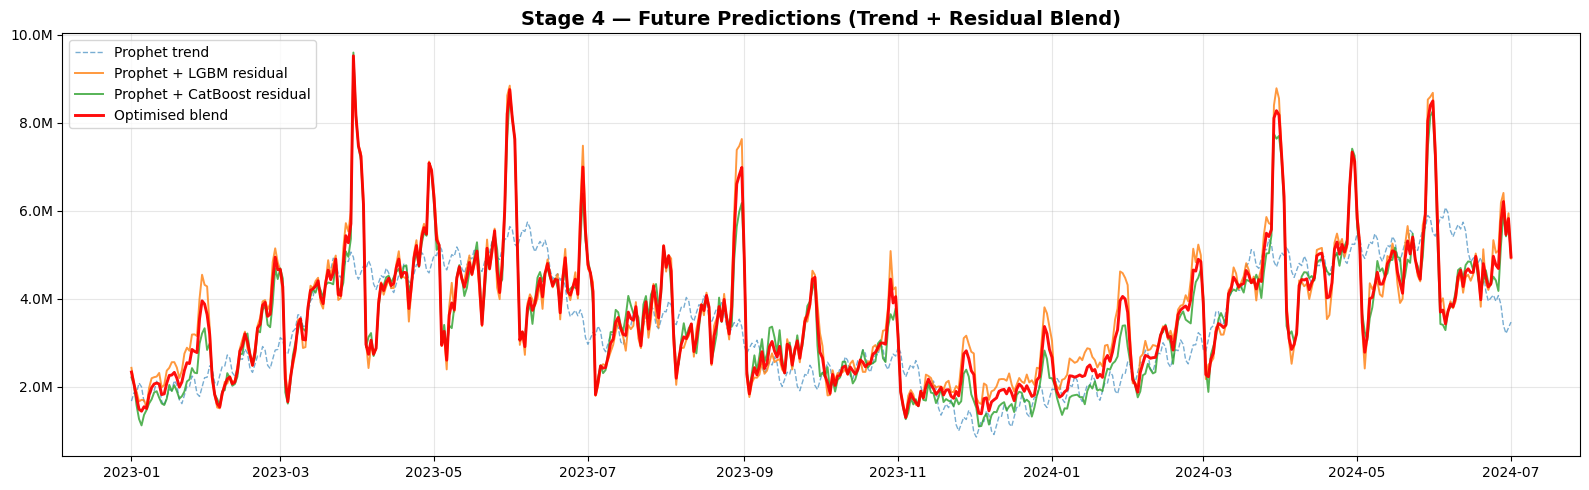

Plot saved: ensemble_test_plot.png


In [8]:
plt.figure(figsize=(16, 5))
plt.title('Stage 4 — Future Predictions (Trend + Residual Blend)', fontsize=14, fontweight='bold')

plt.plot(test['date'], prophet_test_rev, label='Prophet trend', alpha=0.6, lw=1, linestyle='--')
plt.plot(test['date'], lgbm_test_rev, label='Prophet + LGBM residual', alpha=0.8, lw=1.4)
plt.plot(test['date'], cb_test_rev, label='Prophet + CatBoost residual', alpha=0.8, lw=1.4)
plt.plot(test['date'], ensemble_rev, label='Optimised blend', alpha=0.95, lw=2.1, color='red')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ensemble_test_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: ensemble_test_plot.png')

## 8. Save All Outputs

In [9]:
ens_df = pd.DataFrame({
    'date': test['date'].values,
    'prophet_rev': prophet_test_rev,
    'lgbm_rev': lgbm_test_rev,
    'catboost_rev': cb_test_rev,
    'ensemble_rev': ensemble_rev,
})

if ensemble_cogs is not None:
    ens_df['prophet_cogs'] = prophet_test_cogs
    ens_df['lgbm_cogs'] = lgbm_test_cogs
    ens_df['catboost_cogs'] = cb_test_cogs
    ens_df['ensemble_cogs'] = ensemble_cogs

ens_df.to_csv(os.path.join(OUTPUT_DIR, 'ensemble_predictions.csv'), index=False)
print(f'ensemble_predictions.csv saved — {len(ens_df)} rows')

weights = {
    'blend_method': 'scipy_slsqp_mae_on_2021_2022_holdout',
    'backtest_window': {'start': '2021-01-01', 'end': '2022-12-31'},
    'weights': {
        'revenue': {'prophet_lgbm': float(w_rev[0]), 'prophet_catboost': float(w_rev[1])},
        'cogs': {'prophet_lgbm': float(w_cogs[0]), 'prophet_catboost': float(w_cogs[1])} if ensemble_cogs is not None else None,
    },
    'metrics': {
        'revenue': {
            'prophet_trend': s_prophet,
            'prophet_lgbm': s_lgbm_rev,
            'prophet_catboost': s_cb_rev,
            'optimised_blend': s_ens_rev,
        },
        'cogs': {
            'prophet_trend': s_prophet_cogs,
            'prophet_lgbm': s_lgbm_cogs,
            'prophet_catboost': s_cb_cogs,
            'optimised_blend': s_ens_cogs,
        } if ensemble_cogs is not None else None,
    },
}
json.dump(weights, open(os.path.join(OUTPUT_DIR, 'ensemble_weights.json'), 'w'), indent=2)
print('ensemble_weights.json saved')

oof_ens = oof.copy()
oof_ens['ensemble_rev_oof'] = opt_oof_rev
if opt_oof_cogs is not None:
    oof_ens['ensemble_cogs_oof'] = opt_oof_cogs
oof_ens.to_csv(os.path.join(OUTPUT_DIR, 'oof_ensemble.csv'), index=False)
print(f'oof_ensemble.csv saved — {len(oof_ens)} rows')

ensemble_predictions.csv saved — 548 rows
ensemble_weights.json saved
oof_ensemble.csv saved — 730 rows


## 9. Summary

In [10]:
print('=' * 65)
print('STAGE 4 COMPLETE — Residual Blend Summary (Revenue + COGS)')
print('=' * 65)
print()
print(f'  Revenue weights — Prophet+LGBM={w_rev[0]:.3f}   Prophet+CatBoost={w_rev[1]:.3f}')
if ensemble_cogs is not None:
    print(f'  COGS weights    — Prophet+LGBM={w_cogs[0]:.3f}   Prophet+CatBoost={w_cogs[1]:.3f}')
print()
print(f'  Revenue Prophet trend         — MAE={s_prophet["mae"]:>12,.0f}   RMSE={s_prophet["rmse"]:>12,.0f}   R²={s_prophet["r2"]:.4f}')
print(f'  Revenue Prophet+LGBM residual — MAE={s_lgbm_rev["mae"]:>12,.0f}   RMSE={s_lgbm_rev["rmse"]:>12,.0f}   R²={s_lgbm_rev["r2"]:.4f}')
print(f'  Revenue Prophet+Cat residual  — MAE={s_cb_rev["mae"]:>12,.0f}   RMSE={s_cb_rev["rmse"]:>12,.0f}   R²={s_cb_rev["r2"]:.4f}')
print(f'  Revenue Optimised blend       — MAE={s_ens_rev["mae"]:>12,.0f}   RMSE={s_ens_rev["rmse"]:>12,.0f}   R²={s_ens_rev["r2"]:.4f}')

if ensemble_cogs is not None:
    print()
    print(f'  COGS Prophet trend            — MAE={s_prophet_cogs["mae"]:>12,.0f}   RMSE={s_prophet_cogs["rmse"]:>12,.0f}   R²={s_prophet_cogs["r2"]:.4f}')
    print(f'  COGS Prophet+LGBM residual    — MAE={s_lgbm_cogs["mae"]:>12,.0f}   RMSE={s_lgbm_cogs["rmse"]:>12,.0f}   R²={s_lgbm_cogs["r2"]:.4f}')
    print(f'  COGS Prophet+Cat residual     — MAE={s_cb_cogs["mae"]:>12,.0f}   RMSE={s_cb_cogs["rmse"]:>12,.0f}   R²={s_cb_cogs["r2"]:.4f}')
    print(f'  COGS Optimised blend          — MAE={s_ens_cogs["mae"]:>12,.0f}   RMSE={s_ens_cogs["rmse"]:>12,.0f}   R²={s_ens_cogs["r2"]:.4f}')

print()
print(f'  Future Revenue mean = {ensemble_rev.mean():>12,.0f}')
if ensemble_cogs is not None:
    print(f'  Future COGS mean    = {ensemble_cogs.mean():>12,.0f}')
print()
print('  Files saved:')
print('    - ensemble_predictions.csv')
print('    - ensemble_weights.json')
print('    - oof_ensemble.csv')
print('    - ensemble_oof_plot.png')
print('    - ensemble_test_plot.png')

STAGE 4 COMPLETE — Residual Blend Summary (Revenue + COGS)

  Revenue weights — Prophet+LGBM=0.556   Prophet+CatBoost=0.444
  COGS weights    — Prophet+LGBM=1.000   Prophet+CatBoost=0.000

  Revenue Prophet trend         — MAE=     905,367   RMSE=   1,334,063   R²=0.3595
  Revenue Prophet+LGBM residual — MAE=     742,149   RMSE=   1,057,129   R²=0.5978
  Revenue Prophet+Cat residual  — MAE=     750,841   RMSE=   1,078,715   R²=0.5812
  Revenue Optimised blend       — MAE=     710,008   RMSE=   1,013,842   R²=0.6301

  COGS Prophet trend            — MAE=     816,727   RMSE=   1,196,421   R²=0.3195
  COGS Prophet+LGBM residual    — MAE=     667,786   RMSE=     928,937   R²=0.5898
  COGS Prophet+Cat residual     — MAE=     718,228   RMSE=   1,004,264   R²=0.5206
  COGS Optimised blend          — MAE=     667,786   RMSE=     928,937   R²=0.5898

  Future Revenue mean =    3,629,048
  Future COGS mean    =    3,037,001

  Files saved:
    - ensemble_predictions.csv
    - ensemble_weights.j